In [6]:
## Function Definitions 
import numpy as np
from sklearn.preprocessing import StandardScaler
from scipy.stats import multivariate_normal
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
from sklearn.mixture import GaussianMixture
from sklearn.svm import SVC
import scipy.special

class DataPreprocessor:
    def __init__(self):
        self.scaler = StandardScaler()
        
    def prepare_data(self, class1_data, class2_data, class3_data=None):
        """Prepare and split the data into training and test sets."""
        # Combine all data for scaling
        all_train_data = np.vstack((
            class1_data['train'],
            class2_data['train']
        ))
        if class3_data is not None:
            all_train_data = np.vstack((all_train_data, class3_data['train']))
        
        # Fit scaler on training data and transform all data
        self.scaler.fit(all_train_data)
        
        # Transform training data
        scaled_train1 = self.scaler.transform(class1_data['train'])
        scaled_train2 = self.scaler.transform(class2_data['train'])
        scaled_test1 = self.scaler.transform(class1_data['test'])
        scaled_test2 = self.scaler.transform(class2_data['test'])
        
        if class3_data is not None:
            scaled_train3 = self.scaler.transform(class3_data['train'])
            scaled_test3 = self.scaler.transform(class3_data['test'])
            return {
                'train': (scaled_train1, scaled_train2, scaled_train3),
                'test': (scaled_test1, scaled_test2, scaled_test3)
            }
        
        return {
            'train': (scaled_train1, scaled_train2),
            'test': (scaled_test1, scaled_test2)
        }

class GMMBayesClassifier:
    def __init__(self, n_components=1):
        self.n_components = n_components
        self.gmms = []
        self.priors = []
        
    def fit(self, class_data):
        """Fit GMM for each class."""
        total_samples = sum(len(X) for X in class_data)
        
        for X in class_data:
            # Calculate prior probability for this class
            self.priors.append(len(X) / total_samples)
            
            # Fit GMM
            gmm = GaussianMixture(n_components=self.n_components, 
                                covariance_type='full',
                                random_state=42)
            gmm.fit(X)
            self.gmms.append(gmm)
    
    def predict(self, X):
        """Predict class labels using GMM-based Bayes classifier."""
        # Calculate posterior probabilities for each class
        posteriors = []
        for gmm, prior in zip(self.gmms, self.priors):
            posteriors.append(np.exp(gmm.score_samples(X)) * prior)
        
        # Return class with highest posterior probability
        return np.argmax(np.array(posteriors).T, axis=1)

class KNNBayesClassifier:
    def __init__(self, k=1):
        self.k = k
        self.priors = []
    
    def fit(self, class_data):
        """Calculate prior probabilities."""
        total_samples = sum(len(X) for X in class_data)
        self.training_data = class_data
        self.priors = [len(X) / total_samples for X in class_data]
    
    def _estimate_density(self, x, X):
        """Estimate density using KNN method."""
        # Calculate distances to all points
        distances = cdist([x], X)[0]
        # Get the k-th nearest neighbor distance
        k_dist = np.sort(distances)[min(self.k, len(distances)-1)]
        # Calculate volume of hypersphere
        d = X.shape[1]  # dimensionality
        volume = np.pi**(d/2) / scipy.special.gamma(d/2 + 1) * k_dist**d
        # Return density estimate
        return self.k / (len(X) * volume)
    
    def predict(self, X_test):
        """Predict class labels using KNN-based density estimation."""
        predictions = []
        for x in X_test:
            densities = []
            for class_points, prior in zip(self.training_data, self.priors):
                density = self._estimate_density(x, class_points) * prior
                densities.append(density)
            predictions.append(np.argmax(densities))
        return np.array(predictions)

class FDAClassifier:
    def __init__(self, classifier_type='gaussian'):
        self.w = None
        self.classifier_type = classifier_type
        self.gmm = None if classifier_type == 'gaussian' else GaussianMixture(n_components=2)
        
    def fit(self, X1, X2):
        """Fit FDA and classifier."""
        # Calculate means
        mean1 = np.mean(X1, axis=0)
        mean2 = np.mean(X2, axis=0)
        
        # Calculate within-class scatter matrix
        S1 = np.zeros((X1.shape[1], X1.shape[1]))
        S2 = np.zeros((X2.shape[1], X2.shape[1]))
        
        for x in X1:
            diff = (x - mean1).reshape(-1, 1)
            S1 += diff @ diff.T
        for x in X2:
            diff = (x - mean2).reshape(-1, 1)
            S2 += diff @ diff.T
            
        Sw = S1 + S2
        
        # Calculate between-class scatter matrix
        mean_diff = (mean1 - mean2).reshape(-1, 1)
        Sb = mean_diff @ mean_diff.T
        
        # Calculate optimal direction w
        self.w = np.linalg.inv(Sw) @ (mean1 - mean2)
        self.w = self.w / np.linalg.norm(self.w)
        
        # Transform training data
        X1_transformed = self.transform(X1)
        X2_transformed = self.transform(X2)
        
        # Fit classifier on transformed data
        if self.classifier_type == 'gaussian':
            self.mean1 = np.mean(X1_transformed)
            self.mean2 = np.mean(X2_transformed)
            self.std1 = np.std(X1_transformed)
            self.std2 = np.std(X2_transformed)
        else:
            X_combined = np.concatenate([X1_transformed, X2_transformed])
            y_combined = np.concatenate([np.zeros(len(X1)), np.ones(len(X2))])
            self.gmm.fit(X_combined.reshape(-1, 1), y_combined)
        
    def transform(self, X):
        """Project data onto FDA direction."""
        return X @ self.w
    
    def predict(self, X):
        """Predict class labels."""
        X_transformed = self.transform(X)
        
        if self.classifier_type == 'gaussian':
            # Use Gaussian assumption
            pdf1 = np.exp(-0.5 * ((X_transformed - self.mean1) / self.std1) ** 2) / (self.std1 * np.sqrt(2 * np.pi))
            pdf2 = np.exp(-0.5 * ((X_transformed - self.mean2) / self.std2) ** 2) / (self.std2 * np.sqrt(2 * np.pi))
            return np.where(pdf1 > pdf2, 0, 1)
        else:
            # Use GMM
            return self.gmm.predict(X_transformed.reshape(-1, 1))

class Perceptron:
    def __init__(self, learning_rate=0.01, max_iterations=1000):
        self.learning_rate = learning_rate
        self.max_iterations = max_iterations
        self.weights = None
        self.bias = None
        
    def fit(self, X, y):
        """Train the perceptron."""
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        
        for _ in range(self.max_iterations):
            errors = 0
            for xi, target in zip(X, y):
                update = self.learning_rate * (target - self.predict(xi.reshape(1, -1)))
                self.weights += update * xi
                self.bias += update
                errors += int(update != 0.0)
            if errors == 0:
                break
                
    def predict(self, X):
        """Predict class labels."""
        return np.where(np.dot(X, self.weights) + self.bias >= 0.0, 1, -1)

class LogisticRegression:
    def __init__(self, learning_rate=0.01, max_iterations=1000):
        self.learning_rate = learning_rate
        self.max_iterations = max_iterations
        self.weights = None
        self.bias = None
        
    def sigmoid(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))
        
    def fit(self, X, y):
        """Train logistic regression."""
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        
        for _ in range(self.max_iterations):
            linear_model = np.dot(X, self.weights) + self.bias
            y_predicted = self.sigmoid(linear_model)
            
            # Compute gradients
            dw = (1/n_samples) * np.dot(X.T, (y_predicted - y))
            db = (1/n_samples) * np.sum(y_predicted - y)
            
            # Update parameters
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db
            
    def predict(self, X):
        """Predict class labels."""
        linear_model = np.dot(X, self.weights) + self.bias
        y_predicted = self.sigmoid(linear_model)
        return np.where(y_predicted >= 0.5, 1, 0)

class SVMClassifier:
    def __init__(self, kernel='linear', degree=3, gamma='scale', C=1.0):
        self.model = SVC(kernel=kernel, degree=degree, gamma=gamma, C=C)
        
    def fit(self, X, y):
        """Train SVM classifier."""
        self.model.fit(X, y)
        
    def predict(self, X):
        """Predict class labels."""
        return self.model.predict(X)

def plot_decision_regions(X, y, classifier, title, plot_step=0.02):
    """Plot decision regions and data points."""
    # Set up the plot
    plt.figure(figsize=(10, 8))
    
    # Define the minimum and maximum values for the two features
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    
    # Create a mesh grid
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, plot_step),
                          np.arange(x2_min, x2_max, plot_step))
    
    # Flatten the mesh grid points
    mesh_points = np.c_[xx1.ravel(), xx2.ravel()]
    
    # Make predictions on the mesh points
    Z = classifier.predict(mesh_points)
    Z = Z.reshape(xx1.shape)
    
    # Plot the decision regions
    plt.contourf(xx1, xx2, Z, alpha=0.4)
    
    # Plot the data points
    unique_labels = np.unique(y)
    colors = plt.cm.rainbow(np.linspace(0, 1, len(unique_labels)))
    
    for label, color in zip(unique_labels, colors):
        mask = y == label
        plt.scatter(X[mask, 0], X[mask, 1], c=[color], label=f'Class {label}')
    
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title(title)
    plt.legend()
    plt.show()

def plot_fda_projection(X1, X2, fda, title):
    """Plot FDA projection and decision boundary."""
    plt.figure(figsize=(12, 5))
    
    # Plot original 2D data
    plt.subplot(1, 2, 1)
    plt.scatter(X1[:, 0], X1[:, 1], c='red', label='Class 1')
    plt.scatter(X2[:, 0], X2[:, 1], c='blue', label='Class 2')
    plt.arrow(0, 0, fda.w[0], fda.w[1], color='green', head_width=0.1)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title('Original Space with FDA Direction')
    plt.legend()
    
    # Plot 1D projections
    plt.subplot(1, 2, 2)
    proj1 = fda.transform(X1)
    proj2 = fda.transform(X2)
    
    plt.hist(proj1, bins=20, alpha=0.5, color='red', label='Class 1')
    plt.hist(proj2, bins=20, alpha=0.5, color='blue', label='Class 2')
    plt.xlabel('FDA Projection')
    plt.ylabel('Count')
    plt.title('FDA Projected Data')
    plt.legend()
    
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

def evaluate_classifier(y_true, y_pred, class_names=None):
    """Evaluate classifier performance."""
    if class_names is None:
        class_names = [f'Class {i}' for i in range(len(np.unique(y_true)))]
    
    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, 
                                                             average=None)
    conf_matrix = confusion_matrix(y_true, y_pred)
    
    # Calculate mean metrics
    mean_precision = np.mean(precision)
    mean_recall = np.mean(recall)
    mean_f1 = np.mean(f1)
    
    results = {
        'accuracy': accuracy,
        'precision': {class_names[i]: p for i, p in enumerate(precision)},
        'recall': {class_names[i]: r for i, r in enumerate(recall)},
        'f1': {class_names[i]: f for i, f in enumerate(f1)},
        'mean_precision': mean_precision,
        'mean_recall': mean_recall,
        'mean_f1': mean_f1,
        'confusion_matrix': conf_matrix
    }
    
    return results

def print_evaluation_results(results):
    """Print evaluation results in a formatted way."""
    print("\nClassification Results:")
    print(f"Accuracy: {results['accuracy']:.4f}")
    print("\nPer-class metrics:")
    for class_name in results['precision'].keys():
        print(f"\n{class_name}:")
        print(f"Precision: {results['precision'][class_name]:.4f}")
        print(f"Recall: {results['recall'][class_name]:.4f}")
        print(f"F1-score: {results['f1'][class_name]:.4f}")
    
    print("\nMean metrics:")
    print(f"Mean Precision: {results['mean_precision']:.4f}")
    print(f"Mean Recall: {results['mean_recall']:.4f}")
    print(f"Mean F1-score: {results['mean_f1']:.4f}")
    
    print("\nConfusion Matrix:")
    print(results['confusion_matrix'])


In [7]:
# Load and prepare data
class1_data = np.loadtxt('data/LS_data/Class1.txt')
class2_data = np.loadtxt('data/LS_data/Class2.txt')

# Split data into train and test sets
def train_test_split(data, test_size=0.3, random_state=42):
    np.random.seed(random_state)
    indices = np.random.permutation(len(data))
    split_idx = int(len(data) * (1 - test_size))
    return data[indices[:split_idx]], data[indices[split_idx:]]

train1, test1 = train_test_split(class1_data)
train2, test2 = train_test_split(class2_data)

# Preprocess data
preprocessor = DataPreprocessor()
data = preprocessor.prepare_data(
    {'train': train1, 'test': test1},
    {'train': train2, 'test': test2}
)

# Prepare combined training and test data
X_train = np.vstack((data['train'][0], data['train'][1]))
y_train = np.hstack((np.zeros(len(data['train'][0])), np.ones(len(data['train'][1]))))
X_test = np.vstack((data['test'][0], data['test'][1]))
y_test = np.hstack((np.zeros(len(data['test'][0])), np.ones(len(data['test'][1]))))

# Dictionary to store all results
all_results = {}

In [8]:
# 1. GMM-based Bayes Classifier
print("\nTraining GMM-based Bayes Classifier...")
gmm_classifiers = {}
for n_components in [1, 2, 4, 8]:
    gmm_clf = GMMBayesClassifier(n_components=n_components)
    gmm_clf.fit([data['train'][0], data['train'][1]])
    y_pred = gmm_clf.predict(X_test)
    results = evaluate_classifier(y_test, y_pred)
    gmm_classifiers[f'GMM_{n_components}'] = {
        'classifier': gmm_clf,
        'results': results
    }
    all_results[f'GMM_{n_components}'] = results


Training GMM-based Bayes Classifier...



Training KNN-based Bayes Classifier...


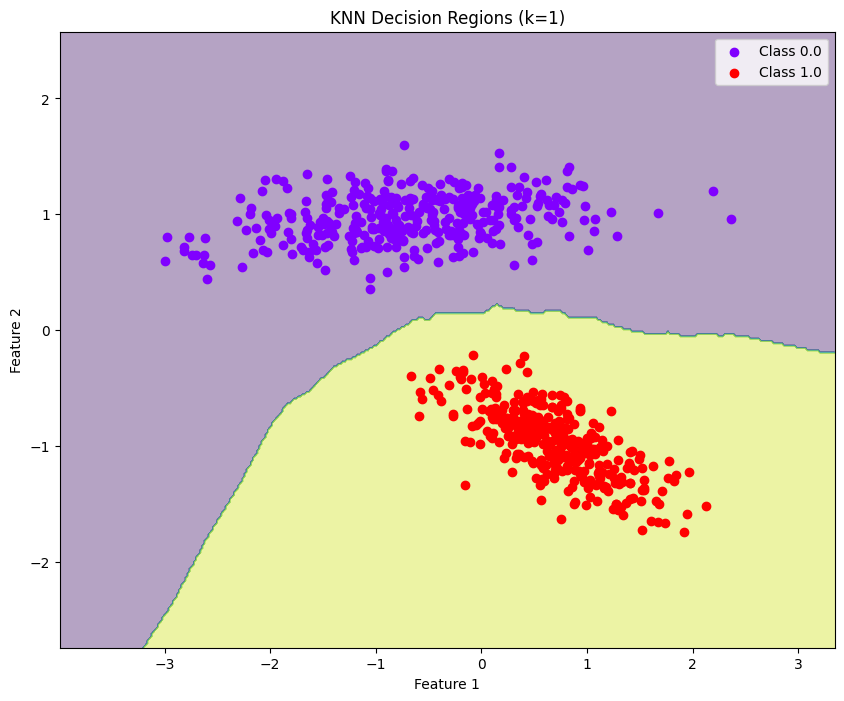

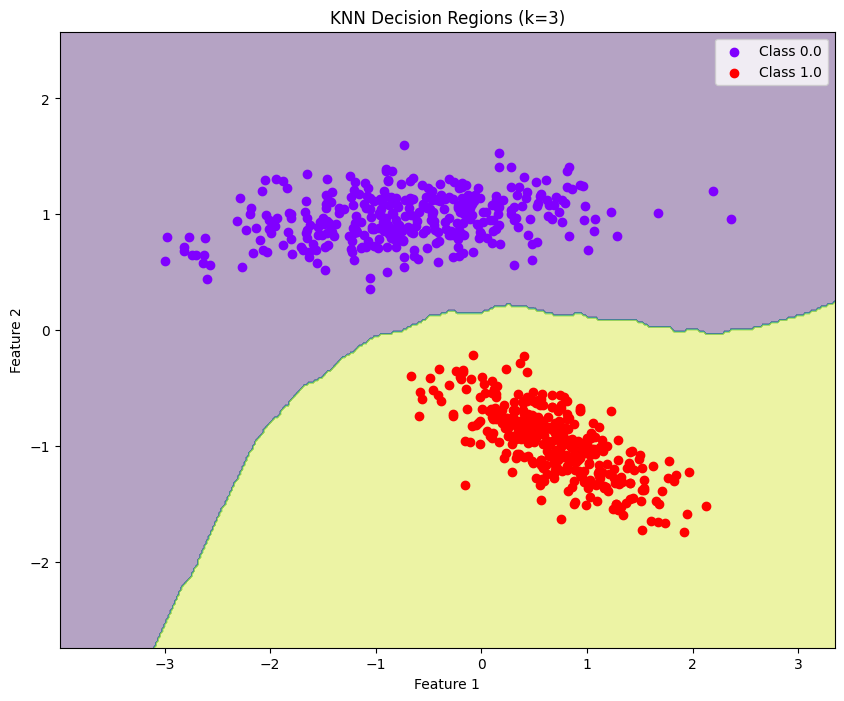

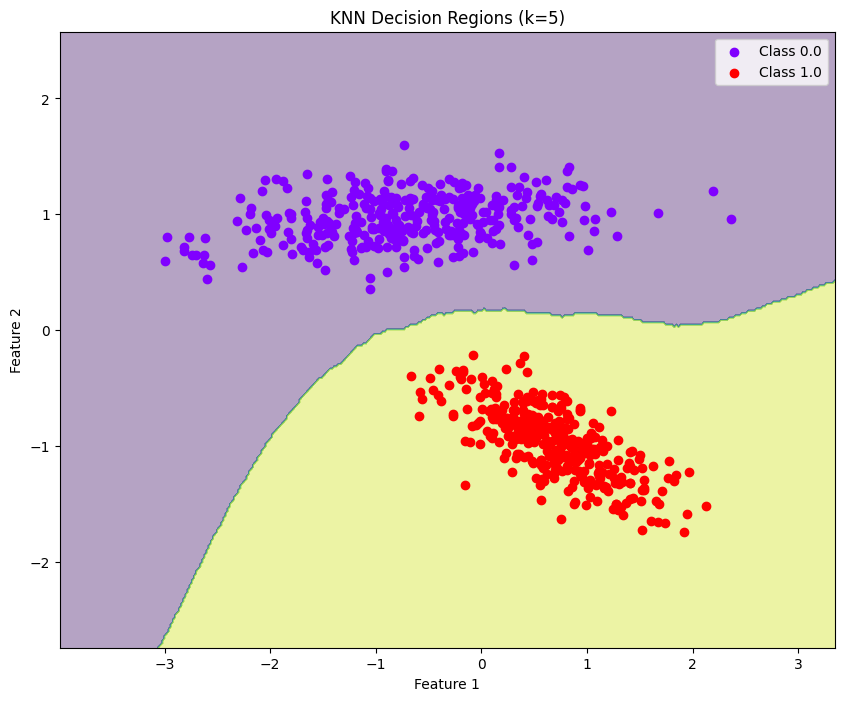

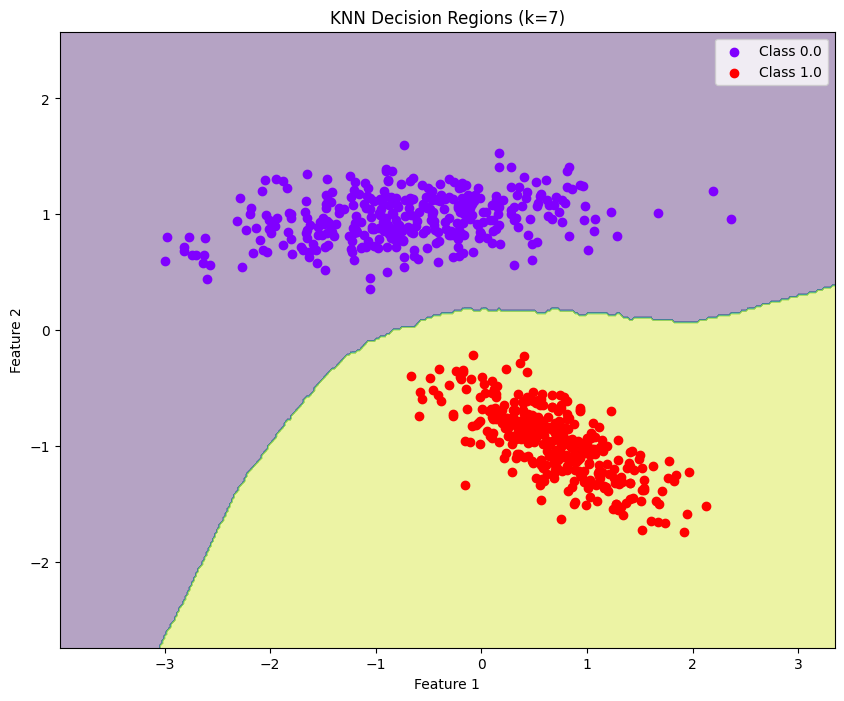

In [9]:
# 2. KNN-based Bayes Classifier
print("\nTraining KNN-based Bayes Classifier...")
knn_classifiers = {}
for k in [1, 3, 5, 7]:
    knn_clf = KNNBayesClassifier(k=k)
    knn_clf.fit([data['train'][0], data['train'][1]])
    y_pred = knn_clf.predict(X_test)
    results = evaluate_classifier(y_test, y_pred)
    knn_classifiers[f'KNN_{k}'] = {
        'classifier': knn_clf,
        'results': results
    }
    all_results[f'KNN_{k}'] = results
    
    # Plot decision regions for KNN
    plot_decision_regions(X_train, y_train, knn_clf, f'KNN Decision Regions (k={k})')


Training FDA Classifier...


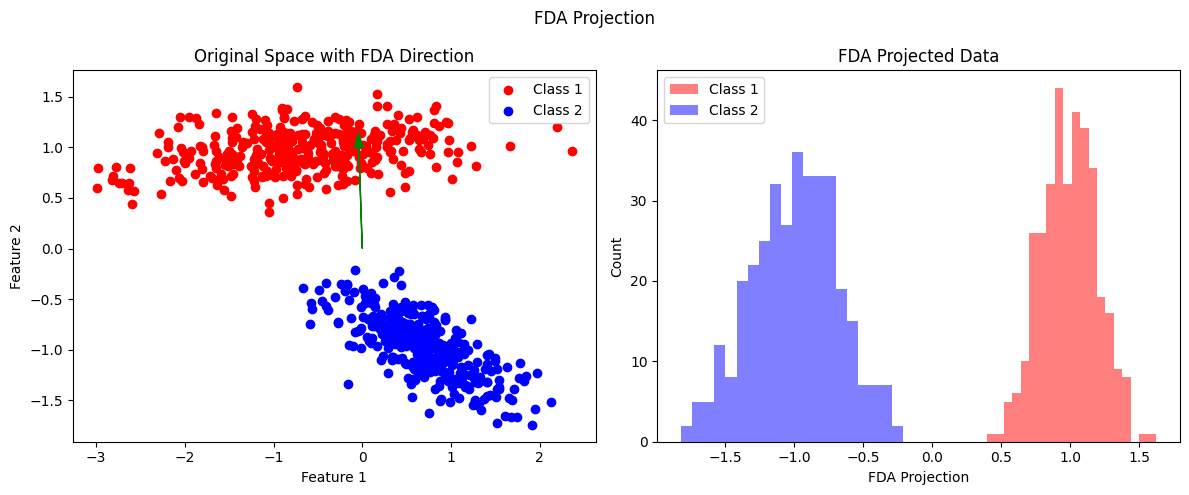

In [10]:
# 3. FDA Classifier
print("\nTraining FDA Classifier...")
# With Gaussian assumption
fda_gaussian = FDAClassifier(classifier_type='gaussian')
fda_gaussian.fit(data['train'][0], data['train'][1])
y_pred = fda_gaussian.predict(X_test)
results = evaluate_classifier(y_test, y_pred)
all_results['FDA_Gaussian'] = results

# With GMM
fda_gmm = FDAClassifier(classifier_type='gmm')
fda_gmm.fit(data['train'][0], data['train'][1])
y_pred = fda_gmm.predict(X_test)
results = evaluate_classifier(y_test, y_pred)
all_results['FDA_GMM'] = results

# Plot FDA projections
plot_fda_projection(data['train'][0], data['train'][1], fda_gaussian, 'FDA Projection')



Training Perceptron...


C:\Users\alpine\AppData\Local\Temp\ipykernel_33480\493101576.py:197: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  errors += int(update != 0.0)


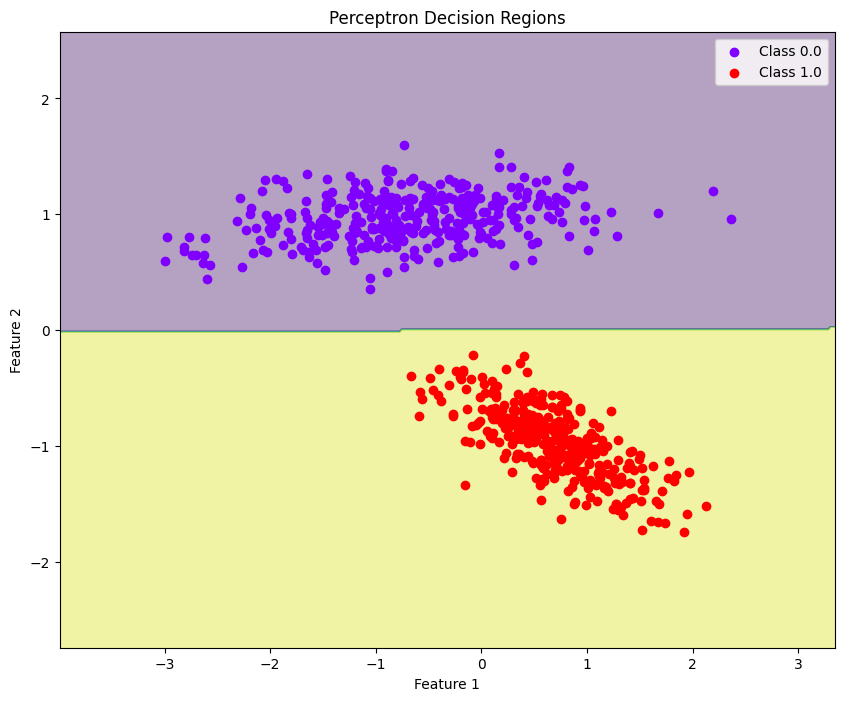

In [11]:

# 4. Perceptron
print("\nTraining Perceptron...")
perceptron = Perceptron(learning_rate=0.01, max_iterations=1000)
perceptron.fit(X_train, 2 * y_train - 1)  # Convert to -1/1 labels
y_pred = (perceptron.predict(X_test) + 1) / 2  # Convert back to 0/1 labels
results = evaluate_classifier(y_test, y_pred)
all_results['Perceptron'] = results

# Plot decision regions for Perceptron
plot_decision_regions(X_train, y_train, perceptron, 'Perceptron Decision Regions')


Training Logistic Regression...


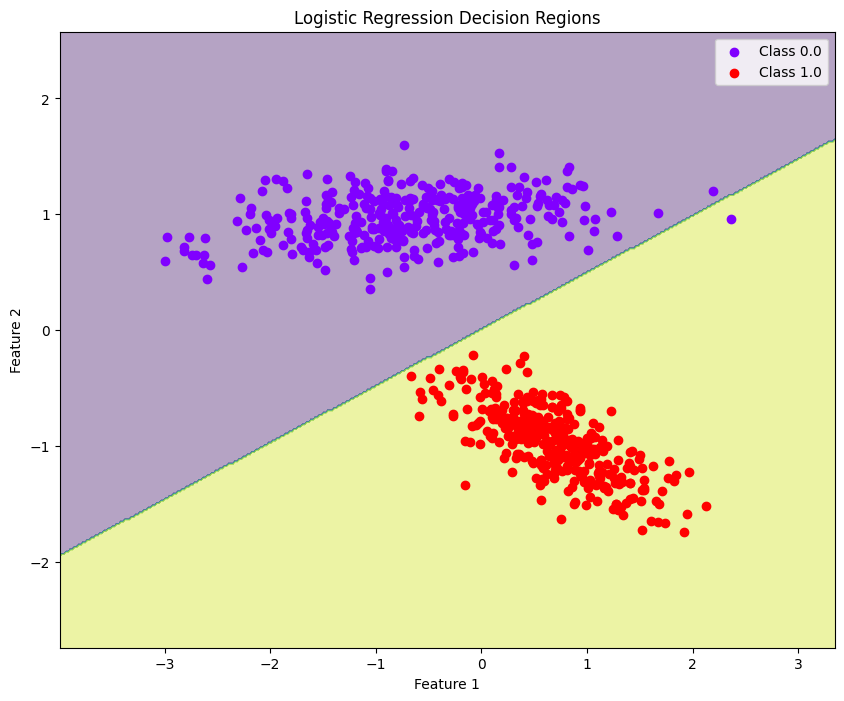

In [12]:
# 5. Logistic Regression
print("\nTraining Logistic Regression...")
logistic = LogisticRegression(learning_rate=0.01, max_iterations=1000)
logistic.fit(X_train, y_train)
y_pred = logistic.predict(X_test)
results = evaluate_classifier(y_test, y_pred)
all_results['Logistic_Regression'] = results

# Plot decision regions for Logistic Regression
plot_decision_regions(X_train, y_train, logistic, 'Logistic Regression Decision Regions')


Training SVM Classifiers...


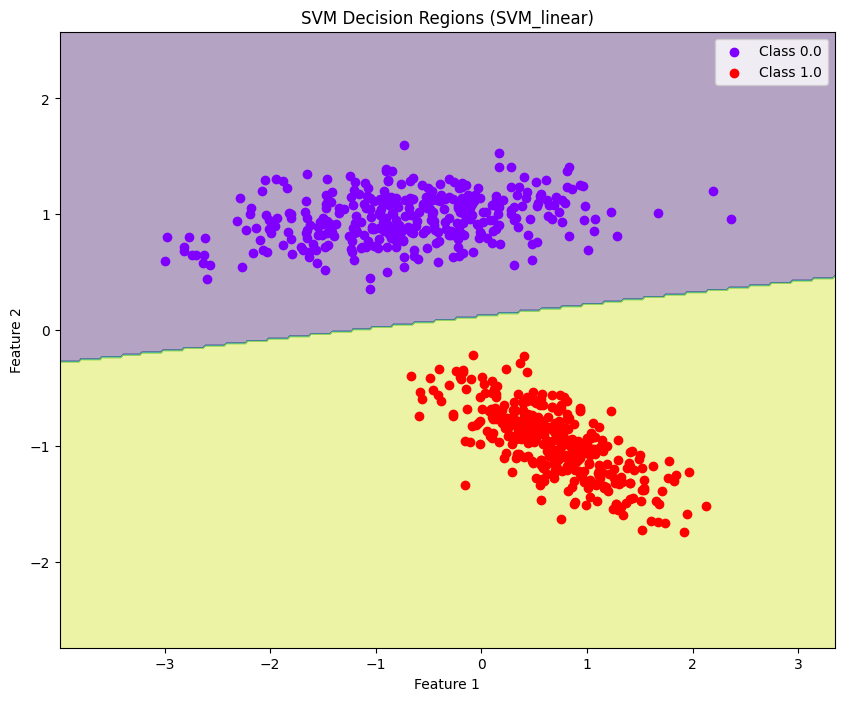

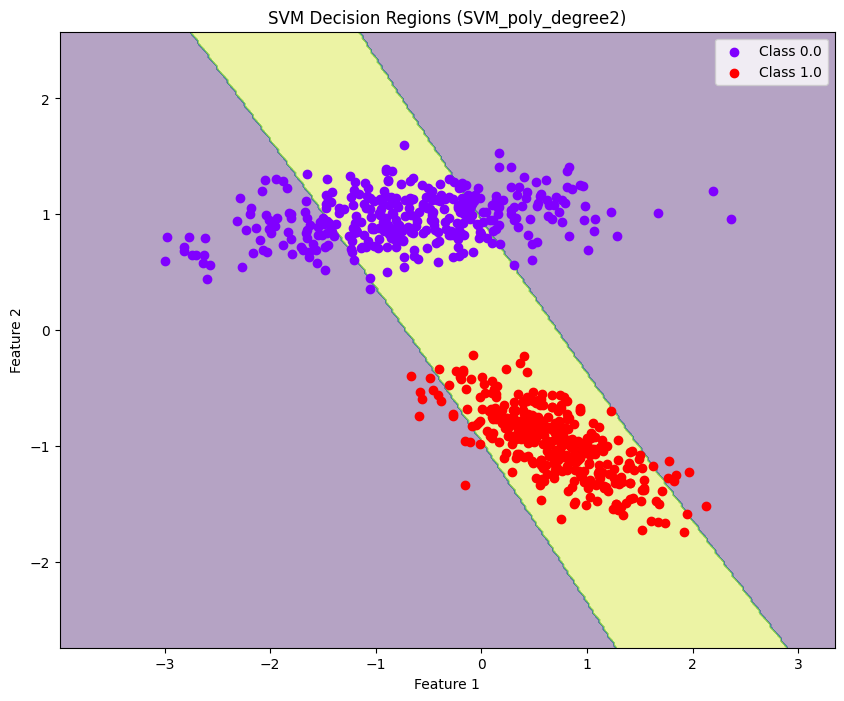

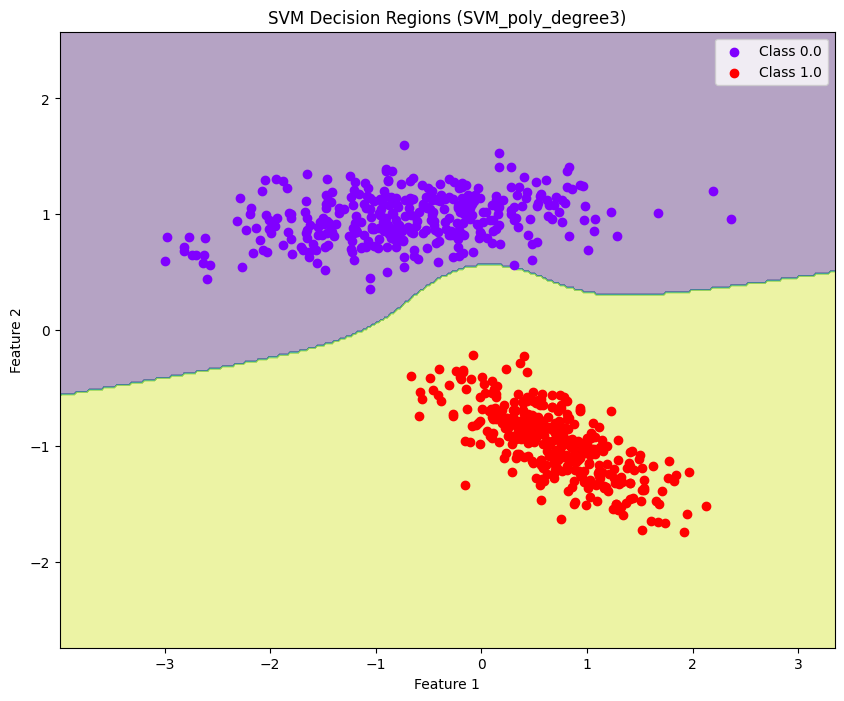

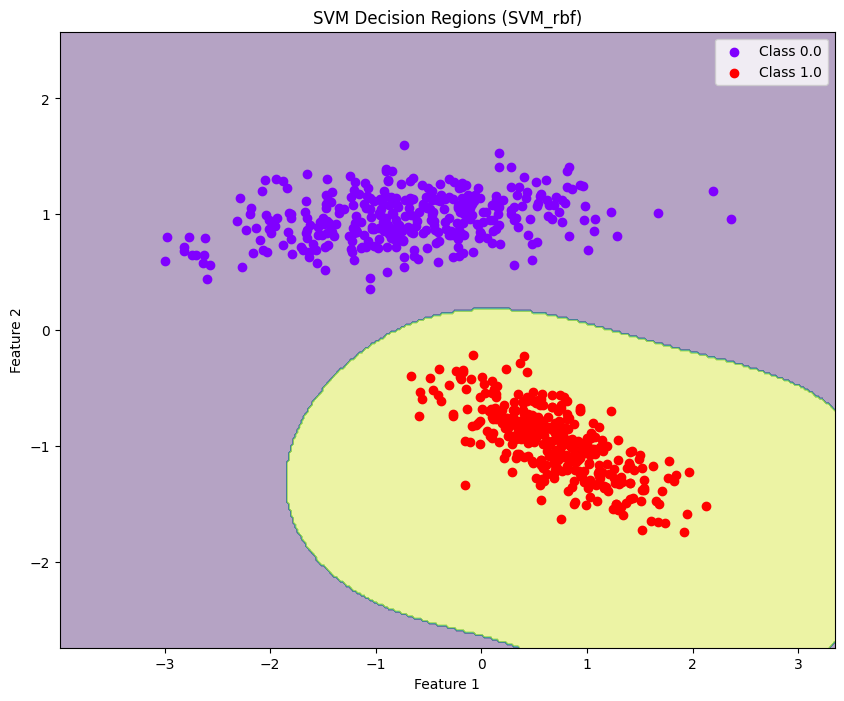

In [13]:

# 6. SVM
print("\nTraining SVM Classifiers...")
svm_configs = [
    {'kernel': 'linear', 'C': 1.0},
    {'kernel': 'poly', 'degree': 2, 'C': 1.0},
    {'kernel': 'poly', 'degree': 3, 'C': 1.0},
    {'kernel': 'rbf', 'gamma': 'scale', 'C': 1.0}
]

for config in svm_configs:
    name = f"SVM_{config['kernel']}"
    if config['kernel'] == 'poly':
        name += f"_degree{config['degree']}"
    
    svm = SVMClassifier(**config)
    svm.fit(X_train, y_train)
    y_pred = svm.predict(X_test)
    results = evaluate_classifier(y_test, y_pred)
    all_results[name] = results
    
    # Plot decision regions for SVM
    plot_decision_regions(X_train, y_train, svm, f'SVM Decision Regions ({name})')

In [14]:
# Print all results
print("\nFinal Results Summary:")
for name, results in all_results.items():
    print(f"\n{name}:")
    print_evaluation_results(results)

# Save results
np.save('classifier_results.npy', all_results)


Final Results Summary:

GMM_1:

Classification Results:
Accuracy: 1.0000

Per-class metrics:

Class 0:
Precision: 1.0000
Recall: 1.0000
F1-score: 1.0000

Class 1:
Precision: 1.0000
Recall: 1.0000
F1-score: 1.0000

Mean metrics:
Mean Precision: 1.0000
Mean Recall: 1.0000
Mean F1-score: 1.0000

Confusion Matrix:
[[150   0]
 [  0 150]]

GMM_2:

Classification Results:
Accuracy: 1.0000

Per-class metrics:

Class 0:
Precision: 1.0000
Recall: 1.0000
F1-score: 1.0000

Class 1:
Precision: 1.0000
Recall: 1.0000
F1-score: 1.0000

Mean metrics:
Mean Precision: 1.0000
Mean Recall: 1.0000
Mean F1-score: 1.0000

Confusion Matrix:
[[150   0]
 [  0 150]]

GMM_4:

Classification Results:
Accuracy: 1.0000

Per-class metrics:

Class 0:
Precision: 1.0000
Recall: 1.0000
F1-score: 1.0000

Class 1:
Precision: 1.0000
Recall: 1.0000
F1-score: 1.0000

Mean metrics:
Mean Precision: 1.0000
Mean Recall: 1.0000
Mean F1-score: 1.0000

Confusion Matrix:
[[150   0]
 [  0 150]]

GMM_8:

Classification Results:
Accurac